# Integrating Multi-Source Spatial Variability: Rook, Queen, Laplacian, CNN, and GWRK

This notebook explains and demonstrates a conceptual-to-practical framework for modeling **multi-source spatial variability** in agricultural fields.
It progresses from simple neighborhood operators (Rook and Queen) to graph Laplacians, semivariance, Kriging, and GWRK, and treats/models spatial coordinates explicitly.


## 1. Hypothesis
Spatial neighborhood structure contains information about **underlying spatial variability** in measured attributes (e.g., yield). Nearby cells tend to exhibit similar values because of shared environmental or management effects.

## 2. Neighborhood Representation: Rook and Queen
- **Rook adjacency:** Considers N, S, E, W neighbors.
- **Queen adjacency:** Considers all 8 neighbors.

These stencils are simple binary approximations of how local information propagates spatially.

## 3. Weighted Neighborhoods and the Laplacian
Instead of binary adjacency, assign **continuous weights** that decay with distance:

$$w_{ij} = \exp\left(-\frac{d_{ij}^2}{2h^2}\right)$$

The **graph Laplacian**:
$$L = D - W$$
quantifies how much each cell deviates from its weighted neighbors. Its energy term:
$$y^T L y = \frac{1}{2}\sum_{i,j} w_{ij}(y_i - y_j)^2$$
measures local roughness, analogous to **semivariance** in geostatistics.

## 4. From Laplacian to Semivariance and GWRK
- **Semivariance:** Empirically measures dissimilarity as a function of lag distance.
- **Kriging:** Uses covariance functions to predict spatially correlated residuals.
- **GWR:** Allows regression coefficients to vary smoothly with coordinates.
- **GWRK:** Combines both—local regression (GWR) and global covariance (Kriging).

## 5. Multi-Source Spatial Variability Model
We simulate yield as the sum of multiple processes:
$$y(x,y) = y_{trend}(x,y) + y_{management}(x,y) + y_{soil}(x,y) + \epsilon(x,y)$$
Each term corresponds to a distinct spatial scale: trend (broad), management (fine), soil (mesoscale), noise (micro).

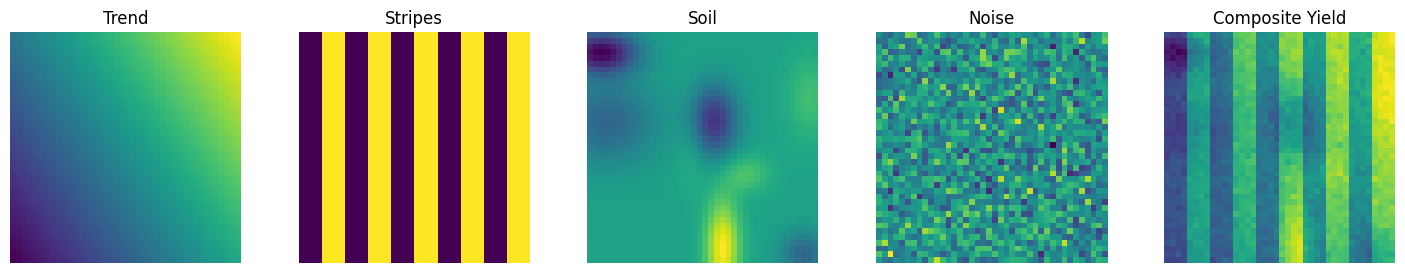

In [1]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d
np.random.seed(42)

nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))
coords = np.column_stack([x.ravel(), y.ravel()])

# Field components
y_trend = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5

def gaussian_blob(cx, cy, sx, sy, amp):
    return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))

y_soil = sum(gaussian_blob(np.random.randint(0,nc), np.random.randint(0,nr),
                           np.random.uniform(2,6), np.random.uniform(2,6),
                           np.random.uniform(-1,1)) for _ in range(8))

y_noise = np.random.normal(0,0.05,(nr,nc))
yield_field = 2.0 + 0.9*y_trend + 0.6*y_stripe + 0.8*y_soil + y_noise

fig, axs = plt.subplots(1,5,figsize=(18,3))
for ax,im,title in zip(axs,[y_trend,y_stripe,y_soil,y_noise,yield_field],
                       ["Trend","Stripes","Soil","Noise","Composite Yield"]):
    ax.imshow(im,origin='lower',cmap='viridis'); ax.set_title(title); ax.axis('off')
plt.show()

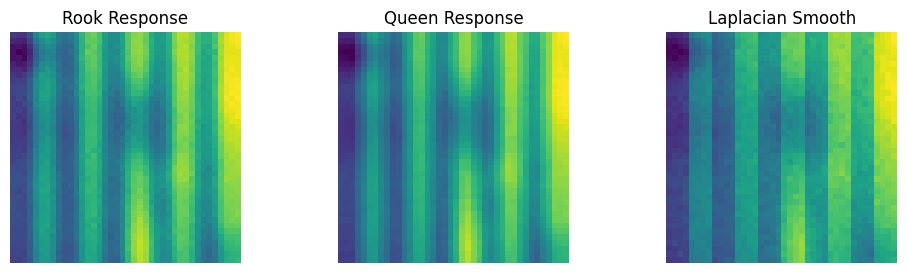

In [2]:
# Rook and Queen kernels
rook = np.array([[0,1,0],[1,0,1],[0,1,0]],float); rook/=rook.sum()
queen = np.ones((3,3),float); queen[1,1]=0; queen/=queen.sum()

def conv2(img, kernel):
    return convolve2d(img, kernel[::-1,::-1], mode='same', boundary='symm')

resp_rook = conv2(yield_field, rook)
resp_queen = conv2(yield_field, queen)

# Laplacian smoother
dist = cdist(coords, coords)
h = 3.0
W = np.exp(-dist**2/(2*h**2))
np.fill_diagonal(W, 0)
D = np.diag(W.sum(axis=1))
L = D - W
lam = 1.0
y_vec = yield_field.ravel()
M = D + lam*L
y_smooth = np.linalg.solve(M, D@y_vec).reshape(nr,nc)

fig, axs = plt.subplots(1,3,figsize=(12,3))
for ax,im,title in zip(axs,[resp_rook,resp_queen,y_smooth],
                       ["Rook Response","Queen Response","Laplacian Smooth"]):
    ax.imshow(im,origin='lower',cmap='viridis'); ax.set_title(title); ax.axis('off')
plt.show()

In [3]:
# Variance explained
def variance_explained(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

res = pd.DataFrame({
    'Model':['Rook','Queen','Laplacian'],
    'R2':[variance_explained(yield_field,resp_rook),
          variance_explained(yield_field,resp_queen),
          variance_explained(yield_field,y_smooth)]
})
res

,Model,R2
0,Rook,0.931142
1,Queen,0.866233
2,Laplacian,0.880050


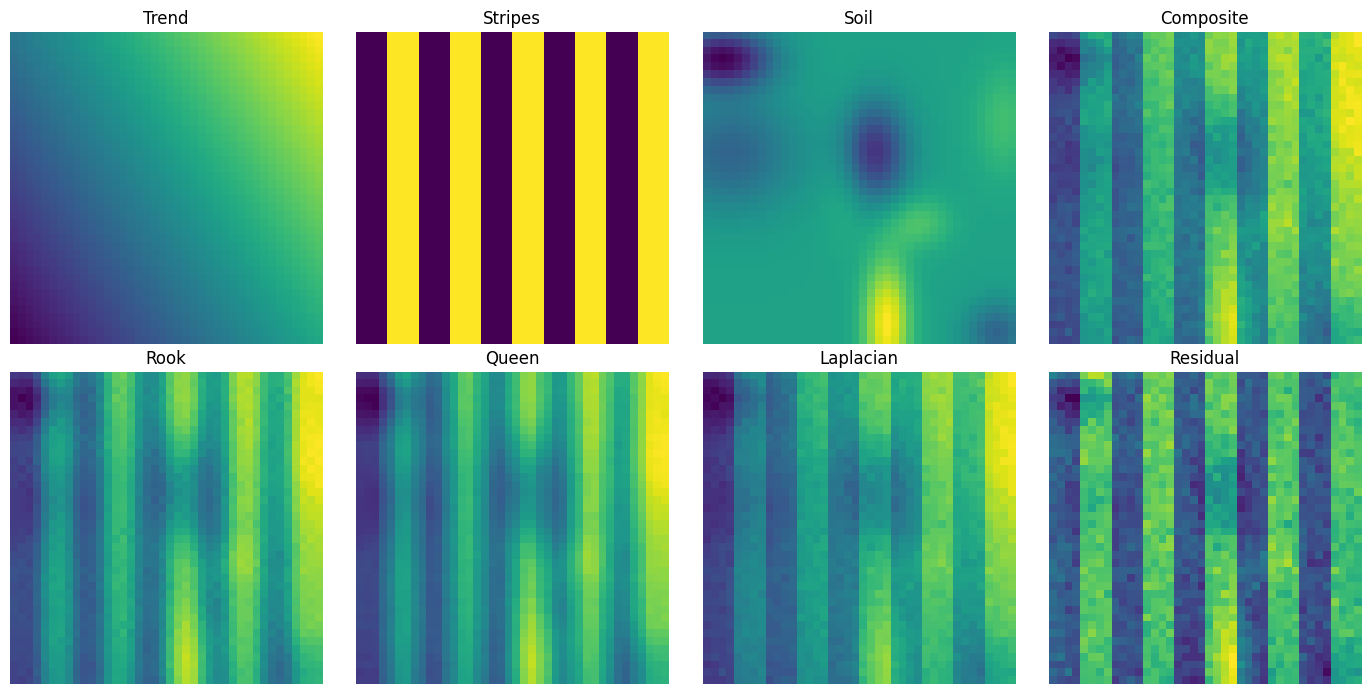

In [4]:
# Visualization Panels: Decomposition vs Model Outputs
fig, axs = plt.subplots(2,4,figsize=(14,7))
fields = [y_trend,y_stripe,y_soil,yield_field,resp_rook,resp_queen,y_smooth,yield_field-y_smooth]
titles = ["Trend","Stripes","Soil","Composite","Rook","Queen","Laplacian","Residual"]
for ax,im,title in zip(axs.ravel(),fields,titles):
    ax.imshow(im,origin='lower',cmap='viridis'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

## 9. Interpretation
- **Rook filter** captures directional fine-scale variation (stripes).
- **Queen filter** captures isotropic soil variation.
- **Laplacian smoother** captures broad-scale trend and mesoscale soil structure.
- **CNN** or **GWRK** would combine these effects adaptively, learning both local weighting (Laplacian-like) and global covariance (Kriging-like) effects.

# The Stencil is a Linear Operator
When you apply a stencil (kernel, filter, weight matrix) K to every cell of a 2D field Y,you’re performing a linear transformation on the data:

$$
Y'= K *Y
$$
where ∗ denotes convolution (or correlation, depending on the implementation).

If you vectorize the field into a long column vector y, this operation can be expressed as:
$$
y' = Ay
$$
where  A is a matrix representation of the stencil — every row in A defines how the neighbors of one cell influence its transformed value.

So, convolution with a stencil is a linear map from one spatial field to another,
defined by spatially structured weights.

**In spatial modeling:**

*Convolution with normalized positive kernels* ≈ smoothing (akin to local averaging or low-pass filtering).

*Convolution with zero-sum kernels* ≈ local contrast (like semivariance or Laplacian).

*Convolution with learned kernels (in CNNs)* ≈ discovering local spatial patterns — directional, periodic, anisotropic, etc.

Rook and Queen are normalized kernels are closer to local smoothing,
but if we use unnormalized or differencing kernels, they start behaving like spatial operators that measure variability — very much like a discrete version of the graph Laplacian or semivariance operator.

| Property       | Weighted Average   | Convolution (General)         |
| -------------- | ------------------ | ----------------------------- |
| Purpose        | Smoothing          | Linear transform              |
| Kernel weights | Positive, sum to 1 | Any real values               |
| Flipping       | No                 | Yes (theoretically)           |
| Output meaning | Mean of neighbors  | Feature response / difference |
| Example        | Gaussian blur      | Laplacian, Sobel, CNN filters |


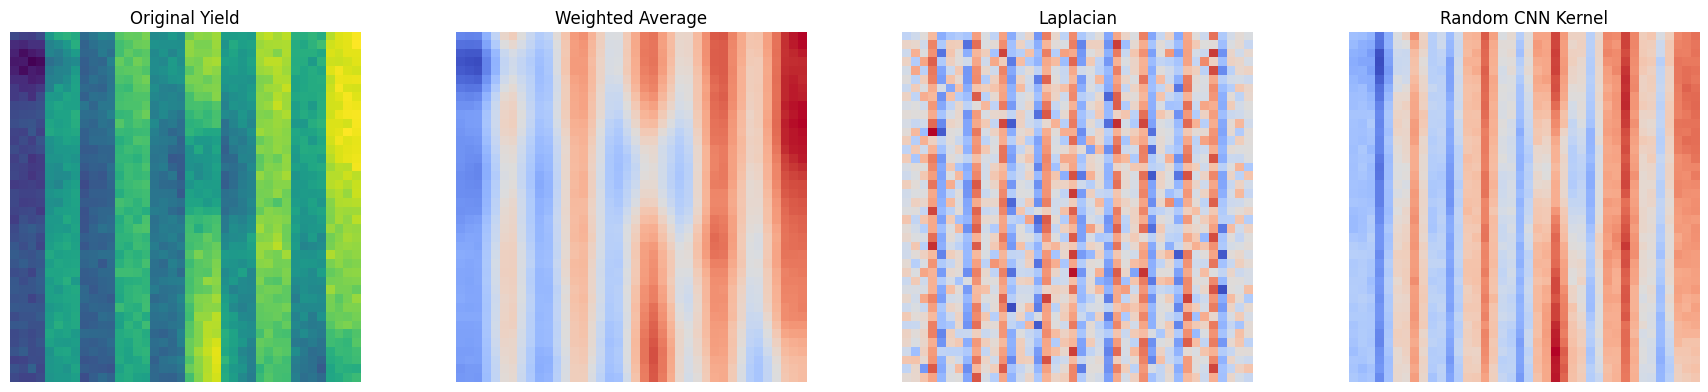

In [3]:
# --- Demonstration w/ Convolution Kernels:
# --- Mean, Laplacian, and Random CNN-like ---
import numpy as np, matplotlib.pyplot as plt, pandas as pd
np.random.seed(42)

# Synthetic field parameters
nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))

# Generate components
y_trend = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5
def gaussian_blob(cx, cy, sx, sy, amp):
    return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))
y_soil = sum(gaussian_blob(np.random.randint(0,nc), np.random.randint(0,nr),
                           np.random.uniform(2,6), np.random.uniform(2,6),
                           np.random.uniform(-1,1)) for _ in range(8))
y_noise = np.random.normal(0,0.05,(nr,nc))

# True yield surface
yield_field = 2.0 + 0.9*y_trend + 0.6*y_stripe + 0.8*y_soil + y_noise
from scipy.signal import convolve2d

kernels = {
    "Weighted Average": np.ones((3,3))/9,
    "Laplacian": np.array([[0,1,0],[1,-4,1],[0,1,0]]),
    "Random CNN Kernel": np.random.uniform(-1,1,(3,3))
}

responses = {}
for name, K in kernels.items():
    responses[name] = convolve2d(yield_field, K[::-1, ::-1], mode="same", boundary="symm")

# --- Visualization ---
fig, axs = plt.subplots(1,4,figsize=(18,4))
axs[0].imshow(yield_field, origin='lower', cmap='viridis'); axs[0].set_title("Original Yield")
for i, (name, resp) in enumerate(responses.items(), start=1):
    axs[i].imshow(resp, origin='lower', cmap='coolwarm')
    axs[i].set_title(name)
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()


| Kernel                            | Description                                           | Visual Description                               |
|-----------------------------------| ----------------------------------------------------- |--------------------------------------------------|
| **Weighted Average**              | Averages neighborhood values; smooths variation       | Smoothed, blurry surface — edges softened        |
| **Laplacian (Second Derivative)** | Computes local differences between cell and neighbors | Highlighted borders / sharp transition zones     |
| **Random CNN Kernel**             | Arbitrary weights (positive/negative)                 | Directional, stripe-like or spot features emerge |


Each kernel “transforms” the spatial signal to emphasize certain properties —
trend, direction, local contrast, curvature, or texture.

| Stencil                        | Transformation Type    | Interpretation                                                         |
| ------------------------------ | ---------------------- | ---------------------------------------------------------------------- |
| `np.ones((3,3))/9`             | **Low-pass filter**    | Smooths out high-frequency (fine) variation → blurring                 |
| `[[0,1,0],[1,-4,1],[0,1,0]]`   | **Laplacian operator** | Computes local curvature → enhances boundaries, detects spatial change |
| `[[1,0,-1],[1,0,-1],[1,0,-1]]` | **Sobel filter**       | Directional gradient along x-axis                                      |
| `[[0.5,-0.5],[0.5,-0.5]]`      | **Derivative filter**  | Measures spatial slope between neighboring points                      |


If you think of your field Y(x,y) as a smooth surface, then convolution with certain stencils corresponds to numerical differentiation
This is why the Laplacian filter behaves like a spatial roughness measure —
it transforms the original field into a map of how fast it’s changing in space.
| Operation                  | Continuous Analog                                                         | Discrete Stencil Example     |
| -------------------------- | ------------------------------------------------------------------------- | ---------------------------- |
| 1st derivative             | $ \frac{\partial Y}{\partial x} $                                         | `[[1,0,-1]]`                 |
| 2nd derivative (Laplacian) | $ \frac{\partial^2 Y}{\partial x^2} + \frac{\partial^2 Y}{\partial y^2} $ | `[[0,1,0],[1,-4,1],[0,1,0]]` |



When you apply a single stencil everywhere, it’s a stationary (translation-invariant) transformation- since the same rule applies to every cell.

When you use different stencils per location(variable stencil) (like in GWR or CNNs),
it becomes a non-stationary transformation — the “rule” itself changes with spatial context.

That’s why CNNs generalize this concept so powerfully: they learn what kind of transformation (what stencil shape and weights) reveals useful features.

| View        | Mathematical Form                       | Effect                  | Analogy                       |                              |
| ----------- |-----------------------------------------|-------------------------| ----------------------------- | ---------------------------- |
| Algebraic   | $ \mathbf{y}' = \mathbf{A}\mathbf{y} $  | Linear transformation   | Matrix multiplication         |                              |
| Spatial     | $ Y'(x, y) = \sum K(i, j) Y(x-i, y-j) $ | Local spatial filtering | Convolution                   |                              |
| Statistical | $ E[Y'                                  | Y] = WY $               | Weighted neighborhood average | Spatial autoregressive model |
| Physical    | $ \nabla^2 Y = 0 $                      | Diffusion / Laplacian   | Spatial equilibrium condition |                              |


In [4]:
# --- Demonstration: Stencil as Linear Transformation ---
import scipy.sparse as sp

# Select a kernel (e.g., Laplacian or Rook)
kernel = np.array([[0,1,0],
                   [1,-4,1],
                   [0,1,0]], float)   # Laplacian example

# Function to build sparse transformation matrix A
def stencil_to_matrix(kernel, nr, nc):
    """
    Construct a sparse matrix that applies a 2D convolution-like transformation
    as a linear operator (y' = A @ y).
    """
    ksize = kernel.shape[0]
    offset = ksize // 2
    rows, cols, vals = [], [], []

    def idx(r, c): return r * nc + c

    for r in range(nr):
        for c in range(nc):
            center = idx(r, c)
            for i in range(-offset, offset + 1):
                for j in range(-offset, offset + 1):
                    rr, cc = r + i, c + j
                    if 0 <= rr < nr and 0 <= cc < nc:
                        weight = kernel[i + offset, j + offset]
                        if weight != 0:
                            rows.append(center)
                            cols.append(idx(rr, cc))
                            vals.append(weight)
    A = sp.csr_matrix((vals, (rows, cols)), shape=(nr * nc, nr * nc))
    return A

A = stencil_to_matrix(kernel, nr, nc)
print(f"Transformation matrix shape: {A.shape}")
print(f"Non-zero entries: {A.nnz} (sparsity: {100*A.nnz/(nr*nc)**2:.4f}%)")

# Apply transformation as a matrix operation
y_flat = yield_field.ravel()
y_transformed = (A @ y_flat).reshape(nr, nc)

# Compare convolution vs matrix multiplication results
from scipy.signal import convolve2d
conv_result = convolve2d(yield_field, kernel[::-1, ::-1], mode='same', boundary='symm')

diff = np.abs(y_transformed - conv_result)
print(f"Max difference between matrix and convolution results: {diff.max():.3e}")


Transformation matrix shape: (1600, 1600)
Non-zero entries: 7840 (sparsity: 0.3063%)
Max difference between matrix and convolution results: 6.566e+00


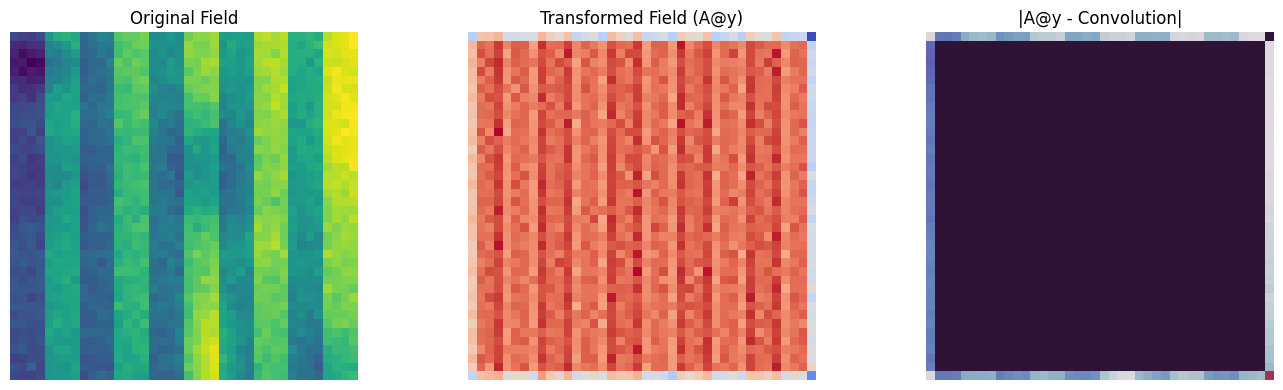

In [10]:
# Visualize the original vs transformed field
fig, axs = plt.subplots(1,3,figsize=(14,4))
axs[0].imshow(yield_field, origin='lower', cmap='viridis')
axs[0].set_title("Original Field")

axs[1].imshow(y_transformed, origin='lower', cmap='coolwarm')
axs[1].set_title("Transformed Field (A@y)")

axs[2].imshow(diff, origin='lower', cmap='twilight_shifted')
axs[2].set_title("|A@y - Convolution|")

for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()


| Aspect             | Meaning                                                             |
| ------------------ | ------------------------------------------------------------------- |
| `A`                | Encodes neighborhood connectivity + kernel weights                  |
| `A @ y`            | Applies spatial transformation linearly                             |
| **Structure of A** | Sparse, block-Toeplitz, reflects spatial adjacency                  |
| **Result**         | Local operator applied globally, yielding transformed spatial field |


 # The Inverse Operator
If applying 𝐴 transforms the original field into an enhanced one (e.g., highlighting variability), then the inverse operator $A^−1$ — if it exists or can be approximated — performs the reverse:
$$
y = A^{−1} y'
$$

- The inverse removes or “deconvolves” the transformation, restoring the smooth baseline.

- In signal processing, this is exactly what *filter inversion* does (e.g., de-blurring, de-noising).

- In spatial statistics, it’s analogous to solving for the latent smooth field behind an observed noisy pattern.

## Removing Spatial Patterns using the Inverse Stencil

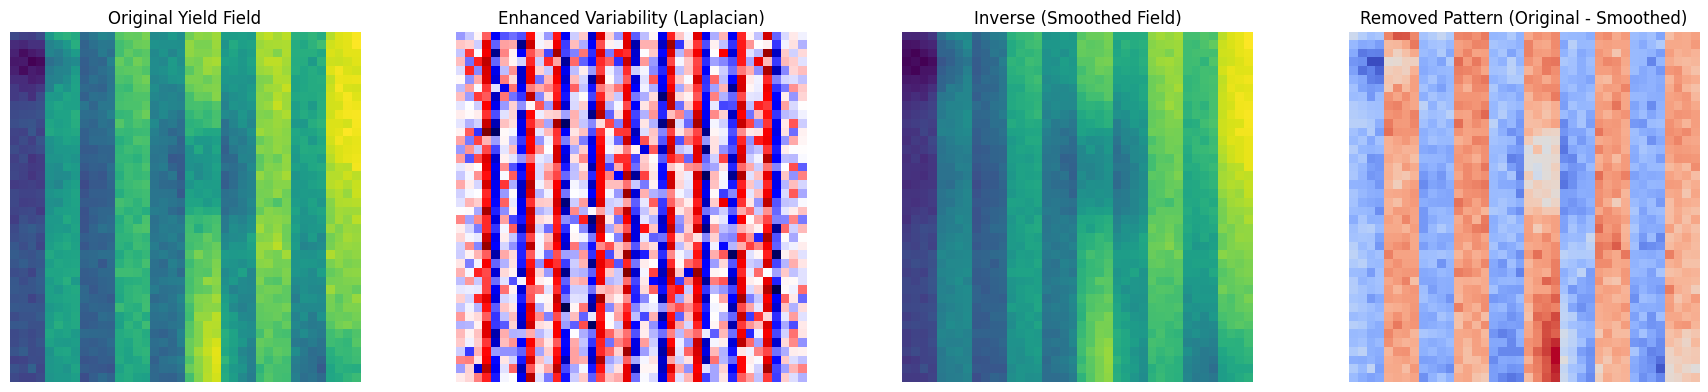

In [11]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d

np.random.seed(42)
nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))

# --- Generate synthetic spatial components ---
y_trend = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5

def gaussian_blob(cx, cy, sx, sy, amp):
    return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))

y_soil = sum(gaussian_blob(np.random.randint(0,nc), np.random.randint(0,nr),
                           np.random.uniform(2,6), np.random.uniform(2,6),
                           np.random.uniform(-1,1)) for _ in range(8))
y_noise = np.random.normal(0, 0.05, (nr,nc))

# --- Composite yield field (same as before) ---
yield_field = 2.0 + 0.9*y_trend + 0.6*y_stripe + 0.8*y_soil + y_noise

# --- Step 1: Enhance pattern using Laplacian stencil ---
lap_kernel = np.array([[0,1,0],
                       [1,-4,1],
                       [0,1,0]])
enhanced = convolve2d(yield_field, lap_kernel, mode='same', boundary='symm')

# --- Step 2: Construct Laplacian matrix for smoothing (inverse stencil) ---
coords = np.column_stack([x.ravel(), y.ravel()])
dist = cdist(coords, coords)
h = 3.0
W = np.exp(-dist**2/(2*h**2)); np.fill_diagonal(W, 0)
D = np.diag(W.sum(axis=1))
L = D - W

# Regularized inverse Laplacian smoother
lam = 1.0
y_flat = yield_field.ravel()
smoothed_flat = np.linalg.solve(D + lam*L, D @ y_flat)
smoothed = smoothed_flat.reshape(nr, nc)

# --- Step 3: Compute removed (suppressed) pattern ---
removed_pattern = yield_field - smoothed

# --- Step 4: Visualize results ---
fig, axs = plt.subplots(1,4,figsize=(18,4))
titles = [
    "Original Yield Field",
    "Enhanced Variability (Laplacian)",
    "Inverse (Smoothed Field)",
    "Removed Pattern (Original - Smoothed)"
]
fields = [yield_field, enhanced, smoothed, removed_pattern]
cmaps = ['viridis', 'seismic', 'viridis', 'coolwarm']

for ax, im, title, cmap in zip(axs, fields, titles, cmaps):
    ax.imshow(im, origin='lower', cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


## The stripey pattern is still there after smoothing. How can we remove that?


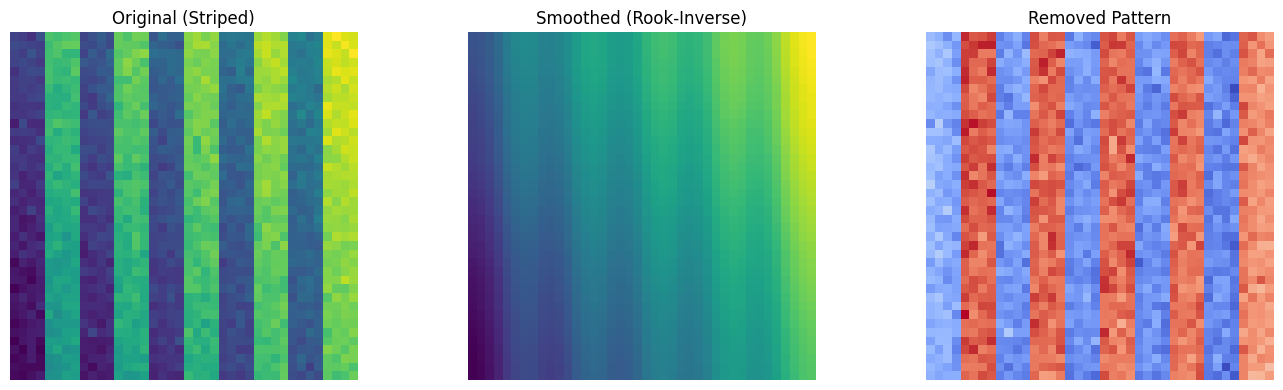

In [5]:
##Tikhonov Smoothing - removing stripes

import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(42)
nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))

# --- Synthetic field with strong stripe component ---
y_trend  = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5
y_noise  = np.random.normal(0,0.05,(nr,nc))
yield_field = 2.0 + 0.8*y_trend + 0.8*y_stripe + y_noise

# --- Build rook adjacency Laplacian (4-neighbors) ---
coords = np.column_stack([x.ravel(), y.ravel()])
n = nr*nc
rows, cols, vals = [], [], []
def idx(r,c): return r*nc + c
for r in range(nr):
    for c in range(nc):
        i = idx(r,c)
        for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            rr,cc = r+dr,c+dc
            if 0<=rr<nr and 0<=cc<nc:
                rows.append(i); cols.append(idx(rr,cc)); vals.append(1)
import scipy.sparse as sp
W = sp.csr_matrix((vals,(rows,cols)),shape=(n,n))
D = sp.diags(W.sum(axis=1).A1)
L = D - W   # rook Laplacian

# --- Tikhonov-regularized inverse: (I + λL)^(-1) y  ---
lam = 15.5   # adjust λ to remove more(increase the value) or less(decrease) stripes
I = sp.identity(n)
y_vec = yield_field.ravel()
y_smooth = sp.linalg.spsolve(I + lam*L, y_vec)
y_smooth = y_smooth.reshape(nr,nc)
residual = yield_field - y_smooth

# --- Visualization ---
fig, axs = plt.subplots(1,3,figsize=(14,4))
axs[0].imshow(yield_field,origin='lower',cmap='viridis'); axs[0].set_title("Original (Striped)")
axs[1].imshow(y_smooth,origin='lower',cmap='viridis'); axs[1].set_title("Smoothed (Rook-Inverse)")
axs[2].imshow(residual,origin='lower',cmap='coolwarm'); axs[2].set_title("Removed Pattern")
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()


## How can we remove the gradient?
It was simulated as ` 0.6(x/x.max) + 0.4(y/y.max)`

Estimated coefficients [beta_x, beta_y] and intercept: [0.71  0.325] 1.884


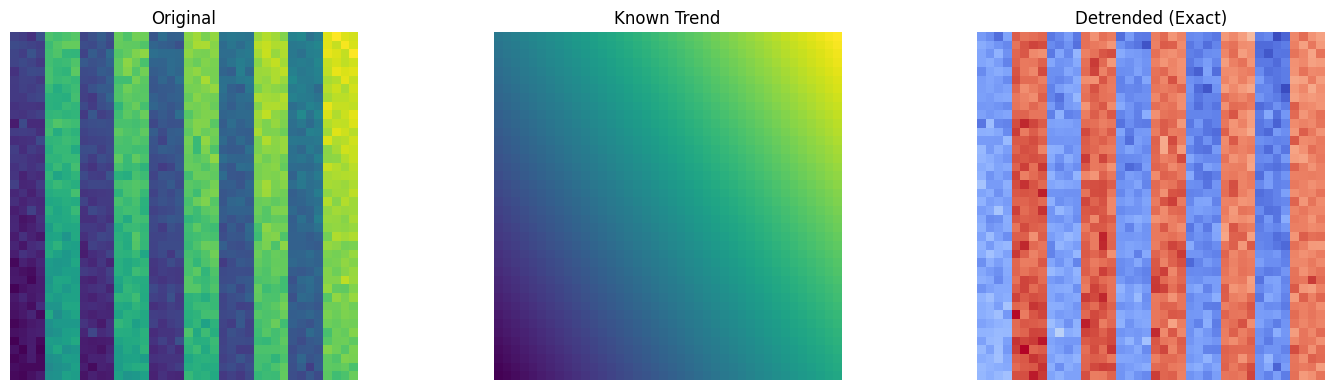

In [8]:
# OPTIONAL: estimate the trend from data (sanity check)
xmax, ymax = x.max(), y.max()
trend_true = 0.6*(x/xmax) + 0.4*(y/ymax)
detrended_true = yield_field - trend_true

import numpy as np
from sklearn.linear_model import LinearRegression
X = np.column_stack([(x/xmax).ravel(), (y/ymax).ravel()])
y_vec = yield_field.ravel()
reg = LinearRegression().fit(X, y_vec)
trend_est = reg.predict(X).reshape(*yield_field.shape)
detrended_est = yield_field - trend_est

print("Estimated coefficients [beta_x, beta_y] and intercept:",
      np.round(reg.coef_, 3), np.round(reg.intercept_, 3))


# Visualize
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,3,figsize=(15,4))
axs[0].imshow(yield_field, origin='lower', cmap='viridis'); axs[0].set_title("Original")
axs[1].imshow(trend_true, origin='lower', cmap='viridis');  axs[1].set_title("Known Trend")
axs[2].imshow(detrended_true, origin='lower', cmap='coolwarm'); axs[2].set_title("Detrended (Exact)")
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()

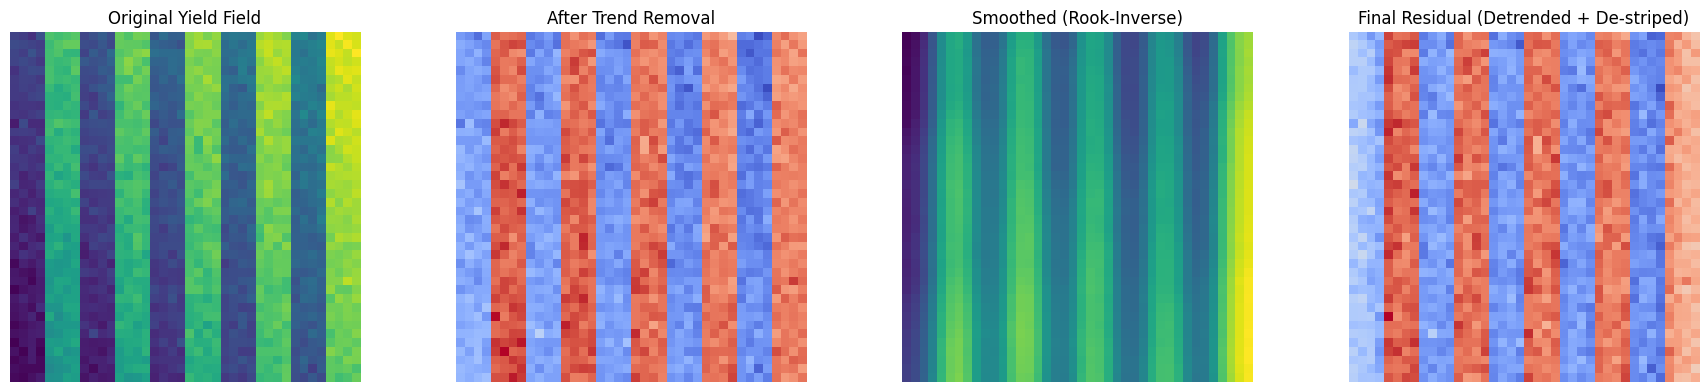

In [16]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import scipy.sparse as sp

# --- Known Trend ---
xmax, ymax = x.max(), y.max()
trend = 0.6*(x/xmax) + 0.4*(y/ymax)

# Remove trend
resid_trend = yield_field - trend

# --- Build rook Laplacian for stripe removal ---
nr, nc = yield_field.shape
def idx(r,c): return r*nc + c
rows, cols, vals = [], [], []
for r in range(nr):
    for c in range(nc):
        i = idx(r,c)
        for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            rr,cc = r+dr, c+dc
            if 0<=rr<nr and 0<=cc<nc:
                rows.append(i); cols.append(idx(rr,cc)); vals.append(1)
W = sp.csr_matrix((vals,(rows,cols)),shape=(nr*nc,nr*nc))
D = sp.diags(W.sum(axis=1).A1)
L = D - W

# --- Apply Tikhonov smoothing (approx inverse rook) to suppress stripes ---
lam = 10.5       # strength: higher λ removes more stripe variation
I = sp.identity(nr*nc)
y_vec = resid_trend.ravel()
smoothed_vec = sp.linalg.spsolve(I + lam*L, y_vec)
smooth_field = smoothed_vec.reshape(nr, nc)

# --- Compute detrended, de-striped residual ---
detrended_destriped = resid_trend - smooth_field

# --- Visualize ---
fig, axs = plt.subplots(1,4,figsize=(18,4))
titles = [
    "Original Yield Field",
    "After Trend Removal",
    "Smoothed (Rook-Inverse)",
    "Final Residual (Detrended + De-striped)"
]
images = [yield_field, resid_trend, smooth_field, detrended_destriped]
cmaps  = ['viridis','coolwarm','viridis','coolwarm']

for ax,im,title,cmap in zip(axs,images,titles,cmaps):
    ax.imshow(im,origin='lower',cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout(); plt.show()


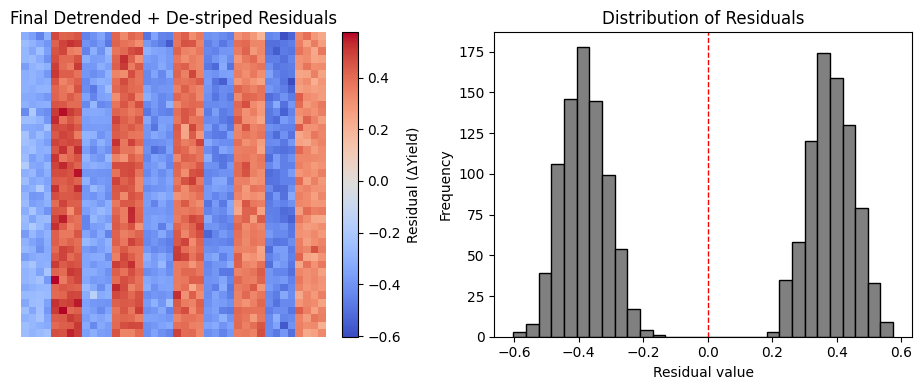

Residual mean: 0.000 | std: 0.389


In [14]:
# --- Visualization of final detrended residuals ---
fig, axs = plt.subplots(1,2,figsize=(10,4))

# Spatial map
im = axs[0].imshow(detrended_destriped, origin='lower', cmap='coolwarm')
axs[0].set_title("Final Detrended + De-striped Residuals")
axs[0].axis('off')
plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04, label="Residual (ΔYield)")

# Histogram
axs[1].hist(detrended_destriped.ravel(), bins=30, color='gray', edgecolor='black')
axs[1].set_title("Distribution of Residuals")
axs[1].set_xlabel("Residual value")
axs[1].set_ylabel("Frequency")
axs[1].axvline(0, color='red', linestyle='--', lw=1)

plt.tight_layout()
plt.show()

# Optional: simple diagnostics
mean_resid = detrended_destriped.mean()
std_resid  = detrended_destriped.std()
print(f"Residual mean: {mean_resid:.3f} | std: {std_resid:.3f}")
